 # Automated Financial Analysis

## Introduction

This project is an automated financial analysis tool designed to evaluate a publicly listed company using financial statement data and market data.

The analysis takes a company ticker as an input and automatically retrieves the relevant financial information before calculating a range of financial performance, profitability, balance sheet and cash flow metrics.

The objective is to provide a structured overview of a company's financial position and historical performance using a combination of financial ratios, growth measures, tables and visualisations.

### Analysis Areas

The analysis is divided into four main areas:

- **Financial Performance** – examines revenue, earnings and EPS growth over time.
- **Profitability** – evaluates margins, return on equity (ROE) and return on assets (ROA).
- **Balance Sheet Strength** – assesses leverage and short-term liquidity using debt-to-equity, current, quick and cash ratios.
- **Cash Flow** – analyses operating cash flow, capital expenditure and free cash flow, including FCF margins and growth.

The results are presented using tables, charts and automated interpretations to make the financial information easier to analyse and compare.

### Methodology

Financial data is retrieved automatically using the company's ticker symbol. Historical financial statements and market data are then processed to calculate the relevant financial metrics.

Where appropriate, historical trends are used rather than relying on a single reporting period. This allows changes in financial performance and financial position to be identified over time.

### Important Considerations

This analysis is intended as a financial analysis and valuation tool rather than a standalone investment decision-making system. The results are dependent on the availability and quality of the underlying financial and market data.

Financial ratios and historical performance should also be considered alongside company-specific factors, industry conditions, broader market conditions and other qualitative information.



### Input of Data

The analysis begins by defining the company to be analysed. The user provides a stock ticker, which is then used to retrieve the relevant company, financial statement and market data.

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Company Information

This section retrieves key information about the selected company using the ticker provided above.

The information provides basic context for the subsequent financial analysis and identifies the company being evaluated.


In [6]:
ticker = input("Enter a stock ticker (e.g. NVDA, AAPL, MSFT): ").upper()

company = yf.Ticker(ticker)

print(f"Loading data for {ticker}...")

Enter a stock ticker (e.g. NVDA, AAPL, MSFT):  MSFT


Loading data for MSFT...


### Company Overview

This section provides a high-level overview of the selected company before moving into the detailed financial analysis.

The purpose is to establish the company's business context and provide a reference point for interpreting the financial results that follow

In [8]:
info = company.info

profile = pd.DataFrame({
    "Company": [info.get("longName", "N/A")],
    "Ticker": [ticker],
    "Sector": [info.get("sector", "N/A")],
    "Industry": [info.get("industry", "N/A")],
    "Country": [info.get("country", "N/A")],
    "Current Price ($)": [info.get("currentPrice", "N/A")],
    "Market Cap ($bn)": [
        round(info.get("marketCap", 0) / 1e9, 2)
        if info.get("marketCap") else "N/A"
    ]
})

profile

,Company,Ticker,Sector,Industry,Country,Current Price ($),Market Cap ($bn)
0,Microsoft Corporation,MSFT,Technology,Software - Infrastructure,United States,508.705,3777.41


In [9]:
print("Company Overview\n")
print(info.get("longBusinessSummary", "No summary available."))

Company Overview

Microsoft Corporation, a technology company, develops and supports a portfolio of technology solutions for individuals and businesses worldwide. Its products include operating systems, server applications, business solution applications, software development tools, desktop and server management tools, and video games; and devices, such as PCs, tablets, gaming and entertainment consoles, other intelligent devices, and related accessories. The company's Productivity and Business Processes segment offers Microsoft 365 Commercial, Enterprise Mobility + Security, Power BI, Exchange, SharePoint, Microsoft Teams, Microsoft 365 Security and Compliance, Microsoft 365 Copilot, and Windows Commercial on-premises and Office licensed on-premises. This segment also provides Microsoft 365 Consumer products and cloud services; LinkedIn, including talent solutions, marketing solutions, subscriptions, and sales solutions; Dynamics 365, a set of cloud-based applications; and on-premises

### Income Statement

The income statement provides an overview of the company's financial performance across the available reporting periods.

The key financial items are used throughout the following sections to assess revenue growth, earnings performance and profitability.

In [10]:
income_statement = company.financials.T

balance_sheet = company.balance_sheet.T

cash_flow = company.cashflow.T

print("Income Statement")
display(income_statement.head())

print("\nBalance Sheet")
display(balance_sheet.head())

print("\nCash Flow Statement")
display(cash_flow.head())

Income Statement


,Tax Effect Of Unusual Items,Tax Rate For Calcs,Normalized EBITDA,Total Unusual Items,Total Unusual Items Excluding Goodwill,Net Income From Continuing Operation Net Minority Interest,Reconciled Depreciation,Reconciled Cost Of Revenue,EBITDA,EBIT,...,Operating Expense,Research And Development,Selling General And Administration,Selling And Marketing Expense,General And Administrative Expense,Other Gand A,Gross Profit,Cost Of Revenue,Total Revenue,Operating Revenue
2026-06-30,1.110650e+09,0.194000,2.017940e+11,5.725000e+09,5.725000e+09,1.337490e+11,3.853400e+10,1.063740e+11,2.075190e+11,1.689850e+11,...,7.022800e+10,3.556200e+10,3.466600e+10,2.671000e+10,7.956000e+09,7.956000e+09,2.254650e+11,1.063740e+11,3.318390e+11,3.318390e+11
2025-06-30,-7.721784e+07,0.176296,1.558830e+11,-4.380000e+08,-4.380000e+08,1.018320e+11,2.943300e+10,8.783100e+10,1.554450e+11,1.260120e+11,...,6.536500e+10,3.248800e+10,3.287700e+10,2.565400e+10,7.223000e+09,7.223000e+09,1.938930e+11,8.783100e+10,2.817240e+11,2.817240e+11
2024-06-30,-1.000900e+08,0.182313,1.322290e+11,-5.490000e+08,-5.490000e+08,8.813600e+10,2.095800e+10,7.411400e+10,1.316800e+11,1.107220e+11,...,6.157500e+10,2.951000e+10,3.206500e+10,2.445600e+10,7.609000e+09,7.609000e+09,1.710080e+11,7.411400e+10,2.451220e+11,2.451220e+11
2023-06-30,-2.850000e+06,0.190000,1.051550e+11,-1.500000e+07,-1.500000e+07,7.236100e+10,1.386100e+10,6.586300e+10,1.051400e+11,9.127900e+10,...,5.752900e+10,2.719500e+10,3.033400e+10,2.275900e+10,7.575000e+09,7.575000e+09,1.460520e+11,6.586300e+10,2.119150e+11,2.119150e+11



Balance Sheet


,Ordinary Shares Number,Share Issued,Net Debt,Total Debt,Tangible Book Value,Invested Capital,Working Capital,Net Tangible Assets,Capital Lease Obligations,Common Stock Equity,...,Raw Materials,Receivables,Accounts Receivable,Allowance For Doubtful Accounts Receivable,Gross Accounts Receivable,Cash Cash Equivalents And Short Term Investments,Other Short Term Investments,Cash And Cash Equivalents,Cash Equivalents,Cash Financial
2026-06-30,7.428435e+09,7.428435e+09,1.935900e+10,5.682600e+10,3.041270e+11,4.826810e+11,3.888500e+10,3.041270e+11,1.653200e+10,4.423870e+11,...,NaN,8.087600e+10,8.087600e+10,-1.040000e+09,8.191600e+10,7.665100e+10,5.571600e+10,2.093500e+10,7.876000e+09,1.305900e+10
2025-06-30,7.434159e+09,7.434159e+09,1.290900e+10,6.058800e+10,2.013660e+11,3.866300e+11,4.991300e+10,2.013660e+11,1.743700e+10,3.434790e+11,...,NaN,6.990500e+10,6.990500e+10,-9.440000e+08,7.084900e+10,9.455500e+10,6.431300e+10,3.024200e+10,1.853100e+10,1.171100e+10
2024-06-30,7.434139e+09,7.434139e+09,3.331500e+10,6.712700e+10,1.216600e+11,3.201070e+11,3.444800e+10,1.216600e+11,1.549700e+10,2.684770e+11,...,3.940000e+08,5.692400e+10,5.692400e+10,-8.300000e+08,5.775400e+10,7.553100e+10,5.721600e+10,1.831500e+10,6.744000e+09,1.157100e+10
2023-06-30,7.432000e+09,7.432000e+09,1.253300e+10,5.996500e+10,1.289710e+11,2.534600e+11,8.010800e+10,1.289710e+11,1.272800e+10,2.062230e+11,...,7.090000e+08,4.868800e+10,4.868800e+10,-6.500000e+08,4.933800e+10,1.112560e+11,7.655200e+10,3.470400e+10,2.622600e+10,8.478000e+09
2022-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.144000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Cash Flow Statement


,Free Cash Flow,Repurchase Of Capital Stock,Repayment Of Debt,Issuance Of Debt,Issuance Of Capital Stock,Capital Expenditure,End Cash Position,Beginning Cash Position,Effect Of Exchange Rate Changes,Changes In Cash,...,Unrealized Gain Loss On Investment Securities,Asset Impairment Charge,Deferred Tax,Deferred Income Tax,Depreciation Amortization Depletion,Depreciation And Amortization,Depreciation,Operating Gains Losses,Gain Loss On Investment Securities,Net Income From Continuing Operations
2026-06-30,6.698700e+10,-2.227100e+10,-3.000000e+09,0.000000e+00,2.009000e+09,-1.159480e+11,2.093500e+10,3.024200e+10,-196000000.0,-9.111000e+09,...,NaN,NaN,1.418900e+10,1.418900e+10,3.853400e+10,3.853400e+10,3.853400e+10,-1.104700e+10,NaN,1.337490e+11
2025-06-30,7.161100e+10,-1.842000e+10,-3.216000e+09,0.000000e+00,2.056000e+09,-6.455100e+10,3.024200e+10,1.831500e+10,63000000.0,1.186400e+10,...,-536000000.0,943000000.0,-7.056000e+09,-7.056000e+09,2.943300e+10,2.943300e+10,2.943300e+10,5.329000e+09,202000000.0,1.018320e+11
2024-06-30,7.407100e+10,-1.725400e+10,-2.907000e+10,2.439500e+10,2.002000e+09,-4.447700e+10,1.831500e+10,3.470400e+10,-210000000.0,-1.617900e+10,...,-146000000.0,206000000.0,-4.738000e+09,-4.738000e+09,2.095800e+10,2.095800e+10,2.095800e+10,1.634000e+09,245000000.0,8.813600e+10
2023-06-30,5.947500e+10,-2.224500e+10,-2.750000e+09,0.000000e+00,1.866000e+09,-2.810700e+10,3.470400e+10,1.393100e+10,-194000000.0,2.096700e+10,...,-303000000.0,30000000.0,-6.059000e+09,-6.059000e+09,1.386100e+10,1.386100e+10,1.386100e+10,4.690000e+08,469000000.0,7.236100e+10
2022-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-509000000.0,101000000.0,NaN,NaN,NaN,NaN,NaN,NaN,-1000000.0,NaN


### Share Price

Historical share price data is used to examine how the company's market value has changed over time.

The historical price data is presented in tabular and graphical form to provide both detailed and visual views of the company's share price performance.

In [11]:
history = company.history(period="5y")

history.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-09-28 00:00:00-04:00,278.128954,279.069497,271.362888,272.101868,43186200,0.0,0.0
2021-09-29 00:00:00-04:00,273.618298,275.221026,271.612471,272.562592,26353700,0.0,0.0
2021-09-30 00:00:00-04:00,274.203629,276.238246,270.278348,270.566284,32343600,0.0,0.0
2021-10-01 00:00:00-04:00,270.758276,278.301749,269.961716,277.457184,30086300,0.0,0.0
2021-10-04 00:00:00-04:00,275.825643,276.161554,268.963598,271.708405,31350700,0.0,0.0


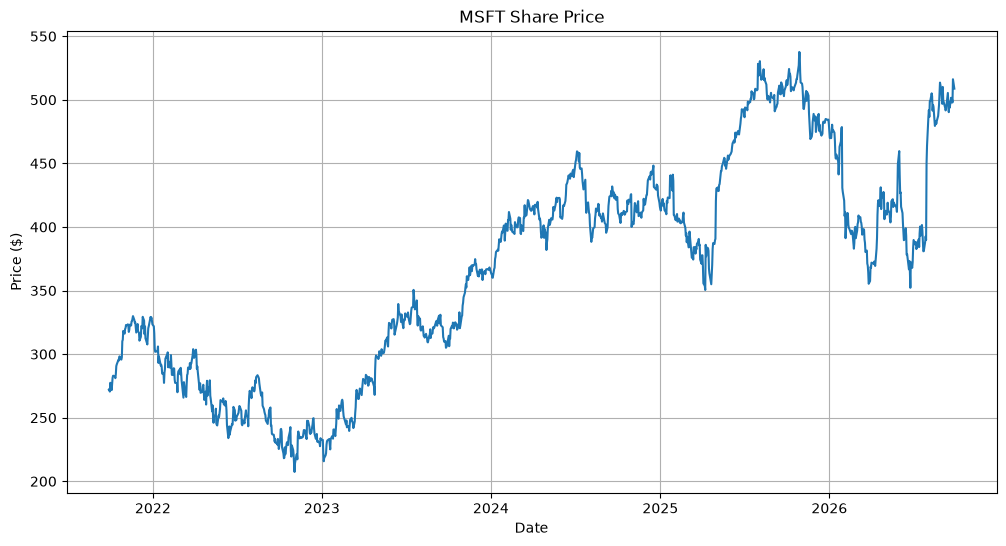

In [12]:
plt.figure(figsize=(12,6))

plt.plot(history.index, history["Close"])

plt.title(f"{ticker} Share Price")

plt.xlabel("Date")

plt.ylabel("Price ($)")

plt.grid(True)

plt.show()

# Financial Performance Analysis

This section evaluates the company's financial performance over time, focusing on changes in revenue, earnings and earnings per share.

Examining these measures together helps identify the direction and consistency of the company's underlying financial performance.

### Revenue Growth

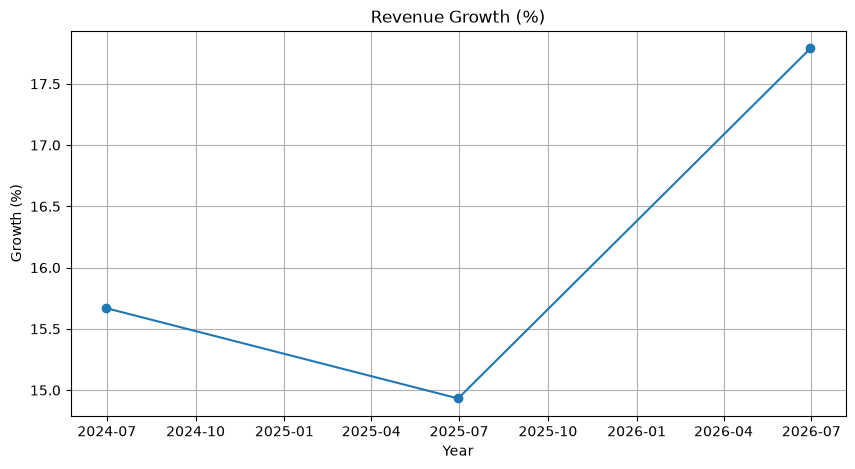

In [13]:
revenue = income_statement["Total Revenue"].sort_index()

revenue_growth = revenue.pct_change(fill_method=None) * 100

revenue_growth

plt.figure(figsize=(10,5))

plt.plot(
    revenue_growth.index,
    revenue_growth,
    marker="o"
)

plt.title("Revenue Growth (%)")
plt.xlabel("Year")
plt.ylabel("Growth (%)")

plt.grid(True)

plt.show()

### Net Income Growth

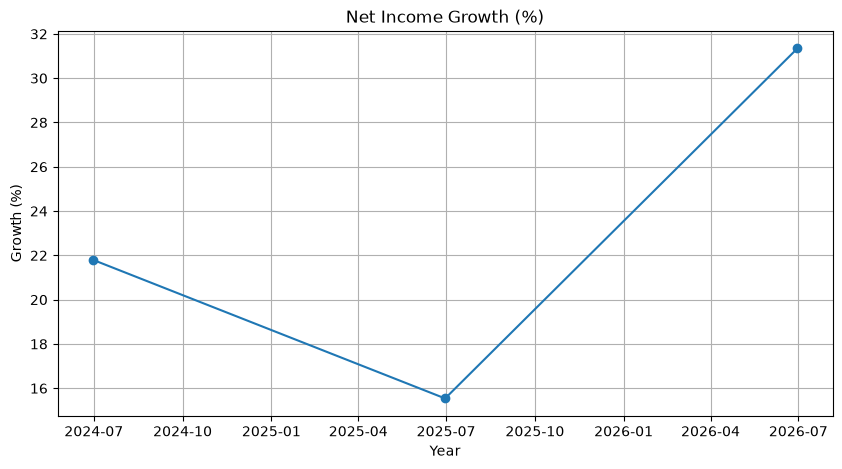

In [14]:
net_income = income_statement["Net Income"]

net_income_growth = net_income.pct_change(-1, fill_method=None) * 100

net_income_growth

plt.figure(figsize=(10,5))

plt.plot(
    net_income_growth.index,
    net_income_growth,
    marker="o"
)

plt.title("Net Income Growth (%)")
plt.xlabel("Year")
plt.ylabel("Growth (%)")

plt.grid(True)

plt.show()

### Revenue Growth vs. Net Income Growth

Comparing revenue growth with net income growth provides an indication of how changes in the company's sales are translating into changes in profitability.

A divergence between the two measures can highlight changes in margins, operating costs, financing costs or other factors affecting net income.

In [15]:
growth_analysis = pd.DataFrame({
    "Revenue Growth (%)": revenue_growth,
    "Net Income Growth (%)": net_income_growth
})

growth_analysis

,Revenue Growth (%),Net Income Growth (%)
2023-06-30,NaN,NaN
2024-06-30,15.669962,21.800417
2025-06-30,14.932156,15.539621
2026-06-30,17.788687,31.342800


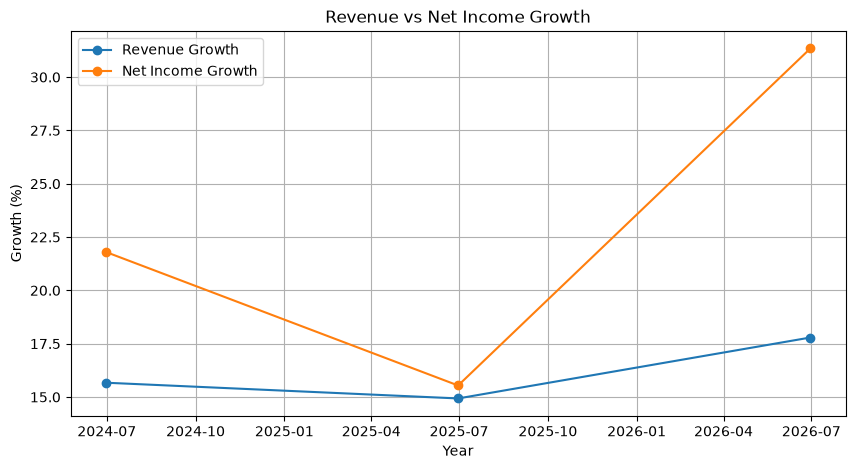

In [16]:
plt.figure(figsize=(10,5))

plt.plot(
    growth_analysis.index,
    growth_analysis["Revenue Growth (%)"],
    marker="o",
    label="Revenue Growth"
)

plt.plot(
    growth_analysis.index,
    growth_analysis["Net Income Growth (%)"],
    marker="o",
    label="Net Income Growth"
)

plt.title("Revenue vs Net Income Growth")

plt.xlabel("Year")
plt.ylabel("Growth (%)")

plt.legend()

plt.grid(True)

plt.show()

### EPS Growth

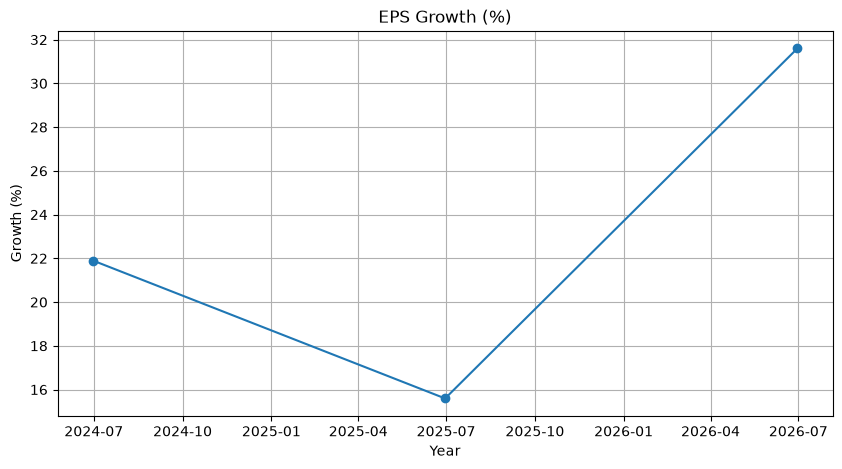

In [17]:
income_statement.columns

eps = income_statement["Diluted EPS"]

eps_growth = eps.pct_change(-1, fill_method=None) * 100

eps_growth

plt.figure(figsize=(10,5))

plt.plot(
    eps_growth.index,
    eps_growth,
    marker="o"
)

plt.title("EPS Growth (%)")

plt.xlabel("Year")

plt.ylabel("Growth (%)")

plt.grid(True)

plt.show()

## Profitability Analysis

This section examines the company's ability to convert revenue and invested resources into profit.

The analysis focuses on profit margins as well as returns generated for shareholders and from the company's asset base.

### Gross Margin

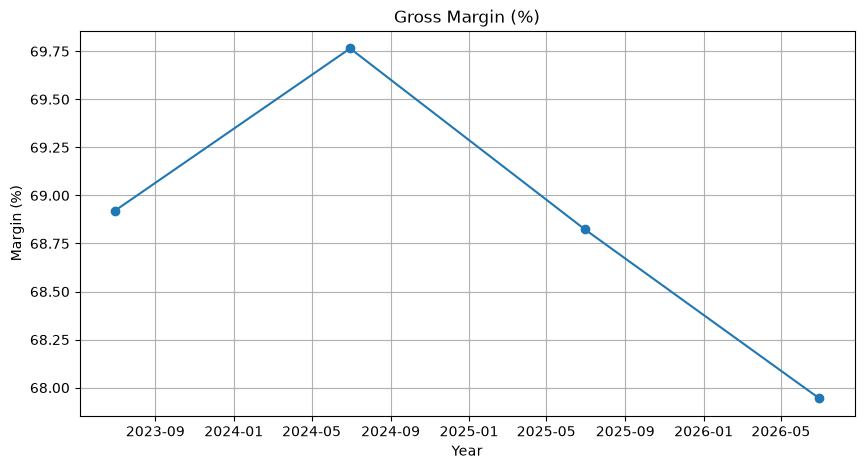

In [18]:
gross_profit = income_statement["Gross Profit"]

revenue = income_statement["Total Revenue"]

gross_margin = (gross_profit / revenue) * 100

plt.figure(figsize=(10,5))

plt.plot(
    gross_margin.index,
    gross_margin,
    marker="o"
)

plt.title("Gross Margin (%)")
plt.xlabel("Year")
plt.ylabel("Margin (%)")

plt.grid(True)

plt.show()

### Operating Margin

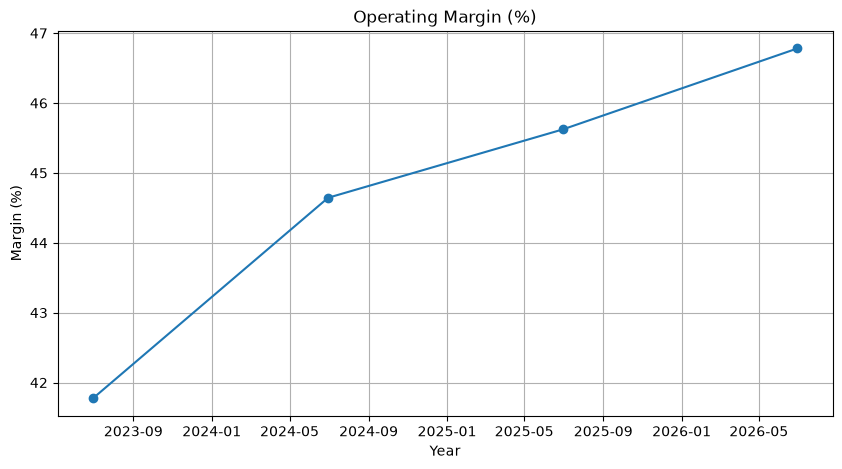

In [19]:
operating_income = income_statement["Operating Income"]

operating_margin = (
    operating_income / revenue
) * 100

plt.figure(figsize=(10,5))

plt.plot(
    operating_margin.index,
    operating_margin,
    marker="o"
)

plt.title("Operating Margin (%)")

plt.xlabel("Year")

plt.ylabel("Margin (%)")

plt.grid(True)

plt.show()

### Net Profit Margin

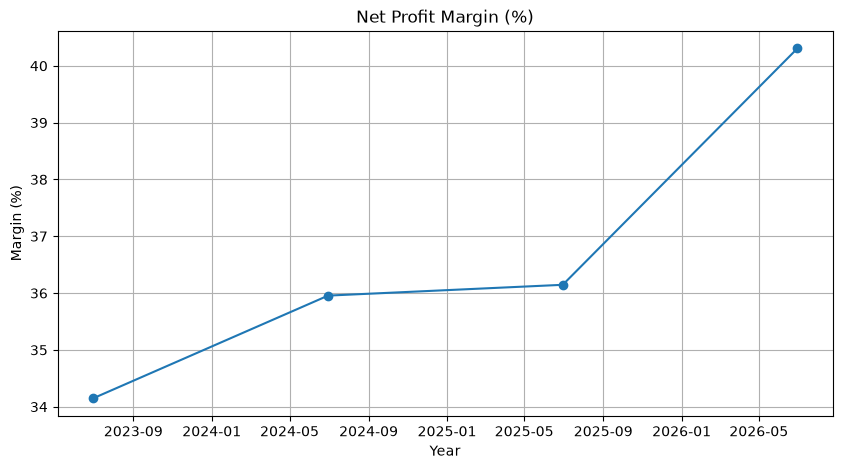

In [20]:
net_income = income_statement["Net Income"]

net_margin = (
    net_income / revenue
) * 100

net_margin

plt.figure(figsize=(10,5))

plt.plot(
    net_margin.index,
    net_margin,
    marker="o"
)

plt.title("Net Profit Margin (%)")

plt.xlabel("Year")

plt.ylabel("Margin (%)")

plt.grid(True)

plt.show()

### Margin Comparison

The table below compares the company's gross, operating and net profit margins across the available reporting periods.

Comparing these margins together provides an overview of how profitability changes as revenue moves through the company's income statement, from gross profit to operating profit and ultimately to net income.

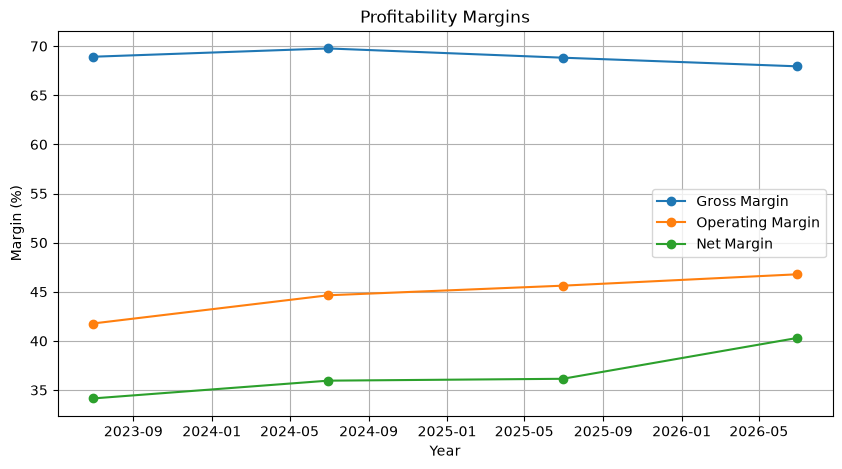

In [21]:
margin_analysis = pd.DataFrame({

    "Gross Margin (%)": gross_margin,
    "Operating Margin (%)": operating_margin,
    "Net Margin (%)": net_margin

})

plt.figure(figsize=(10,5))

plt.plot(
    margin_analysis.index,
    margin_analysis["Gross Margin (%)"],
    marker="o",
    label="Gross Margin"
)

plt.plot(
    margin_analysis.index,
    margin_analysis["Operating Margin (%)"],
    marker="o",
    label="Operating Margin"
)

plt.plot(
    margin_analysis.index,
    margin_analysis["Net Margin (%)"],
    marker="o",
    label="Net Margin"
)


plt.title("Profitability Margins")

plt.xlabel("Year")

plt.ylabel("Margin (%)")

plt.legend()

plt.grid(True)

plt.show()

### Return on Equity (ROE)

In [22]:
equity = balance_sheet["Stockholders Equity"]

roe = (
    net_income / equity
) * 100

roe

2022-06-30          NaN
2023-06-30    35.088715
2024-06-30    32.828138
2025-06-30    29.647227
2026-06-30    30.233483
Freq: YE-JUN, dtype: float64

### Return on Assets (ROA)

In [23]:
assets = balance_sheet["Total Assets"]
roa = (
    net_income / assets
) * 100

roa

2022-06-30          NaN
2023-06-30    17.564373
2024-06-30    17.208584
2025-06-30    16.450970
2026-06-30    17.636238
Freq: YE-JUN, dtype: float64

### Profitability Summary

In [24]:
profitability_summary = pd.DataFrame({

    "Gross Margin (%)": gross_margin,
    "Operating Margin (%)": operating_margin,
    "Net Margin (%)": net_margin,
    "ROE (%)": roe,
    "ROA (%)": roa

})

profitability_summary

,Gross Margin (%),Operating Margin (%),Net Margin (%),ROE (%),ROA (%)
2022-06-30,NaN,NaN,NaN,NaN,NaN
2023-06-30,68.920086,41.772881,34.146238,35.088715,17.564373
2024-06-30,69.764444,44.644300,35.955973,32.828138,17.208584
2025-06-30,68.823742,45.621956,36.146015,29.647227,16.450970
2026-06-30,67.944093,46.780818,40.305389,30.233483,17.636238


## Balance Sheet Analysis

This section evaluates the company's financial structure and short-term liquidity using key balance sheet ratios.

The analysis focuses on leverage and the company's ability to meet its short-term obligations.

### Debt-to-Equity Ratio

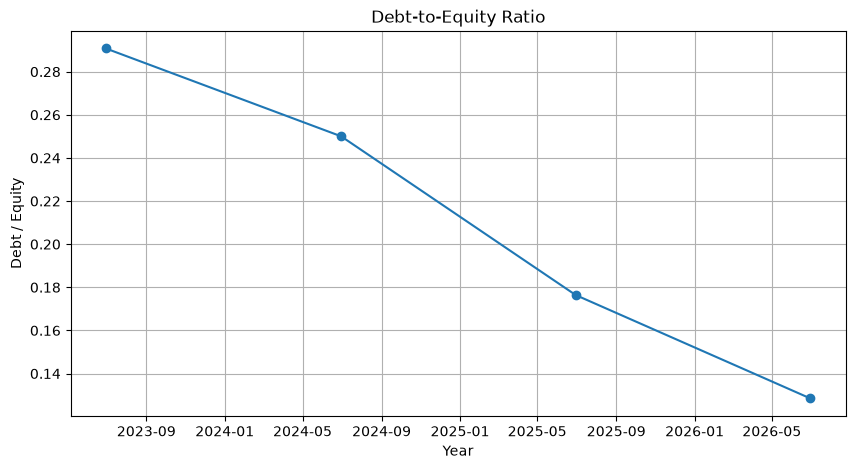

In [25]:
debt = balance_sheet["Total Debt"]
equity = balance_sheet["Stockholders Equity"]

debt_to_equity = debt / equity

plt.figure(figsize=(10,5))

plt.plot(
    debt_to_equity.index,
    debt_to_equity,
    marker="o"
)

plt.title("Debt-to-Equity Ratio")

plt.xlabel("Year")

plt.ylabel("Debt / Equity")

plt.grid(True)

plt.show()

### Current Ratio

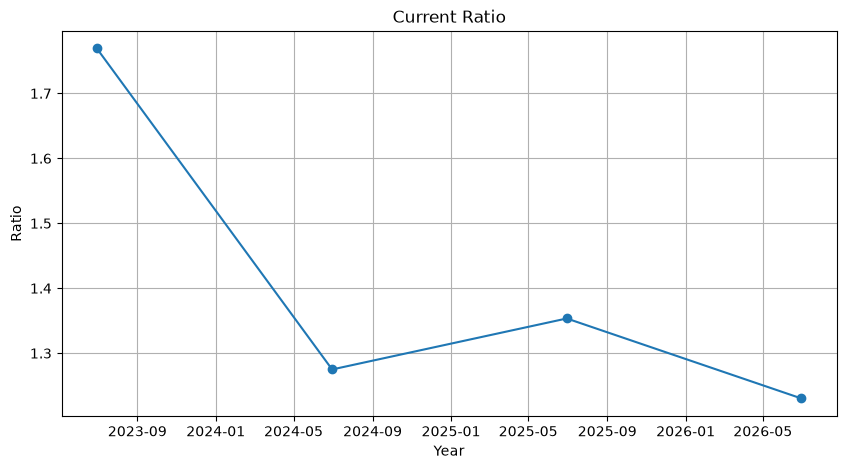

In [26]:
current_assets = balance_sheet["Current Assets"]

current_liabilities = balance_sheet["Current Liabilities"]

current_ratio = (
    current_assets / current_liabilities
)
plt.figure(figsize=(10,5))

plt.plot(
    current_ratio.index,
    current_ratio,
    marker="o"
)

plt.title("Current Ratio")

plt.xlabel("Year")

plt.ylabel("Ratio")

plt.grid(True)

plt.show()

### Quick Ratio

In [27]:
cash = balance_sheet["Cash And Cash Equivalents"]

receivables = balance_sheet["Accounts Receivable"]

quick_ratio = (
    cash + receivables
) / current_liabilities

quick_ratio

2026-06-30    0.603056
2025-06-30    0.709166
2024-06-30    0.600538
2023-06-30    0.800699
2022-06-30         NaN
dtype: float64

### Cash Ratio

In [28]:
cash_ratio = (
    cash / current_liabilities
)

cash_ratio

2026-06-30    0.124004
2025-06-30    0.214151
2024-06-30    0.146186
2023-06-30    0.333215
2022-06-30         NaN
dtype: float64

### Balance Sheet Summary

In [29]:
balance_summary = pd.DataFrame({

    "Debt / Equity": debt_to_equity,
    "Current Ratio": current_ratio,
    "Quick Ratio": quick_ratio,
    "Cash Ratio": cash_ratio

})

balance_summary

,Debt / Equity,Current Ratio,Quick Ratio,Cash Ratio
2026-06-30,0.128453,1.230327,0.603056,0.124004
2025-06-30,0.176395,1.353446,0.709166,0.214151
2024-06-30,0.250029,1.274955,0.600538,0.146186
2023-06-30,0.290777,1.769167,0.800699,0.333215
2022-06-30,NaN,NaN,NaN,NaN


## Balance Sheet Interpretation

The balance sheet analysis evaluates the company's ability to manage financial obligations.

Key considerations:
- Lower debt-to-equity generally indicates lower financial leverage.
- A current ratio above 1 suggests the company can meet short-term liabilities.
- Strong cash reserves provide resilience during periods of economic uncertainty.

These metrics should be interpreted alongside industry benchmarks as acceptable levels vary significantly between sectors.

## Cash Flow Analysis

Cash flow analysis examines how the company generates and uses cash.

The analysis focuses on operating cash flow, capital expenditure and free cash flow, as well as the relationship between free cash flow and revenue.

### Operating Cash Flow

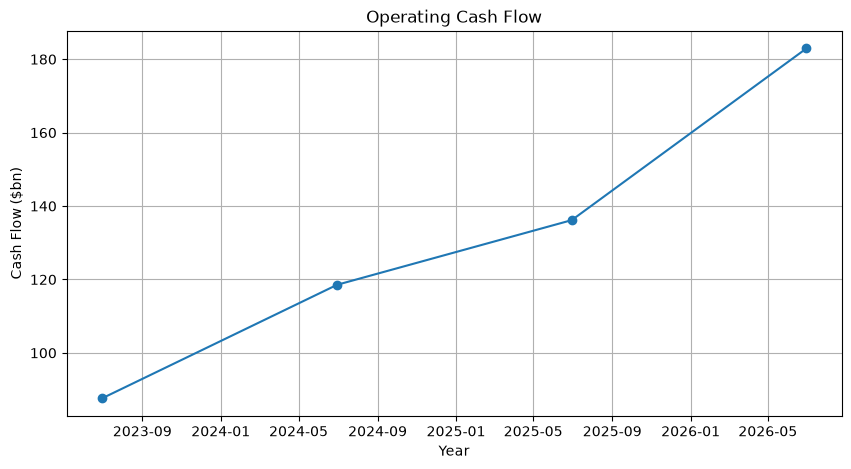

In [30]:
operating_cash_flow = cash_flow["Operating Cash Flow"]

operating_cash_flow

plt.figure(figsize=(10,5))

plt.plot(
    operating_cash_flow.index,
    operating_cash_flow / 1e9,
    marker="o"
)

plt.title("Operating Cash Flow")

plt.xlabel("Year")

plt.ylabel("Cash Flow ($bn)")

plt.grid(True)

plt.show()

### Capital Expenditure

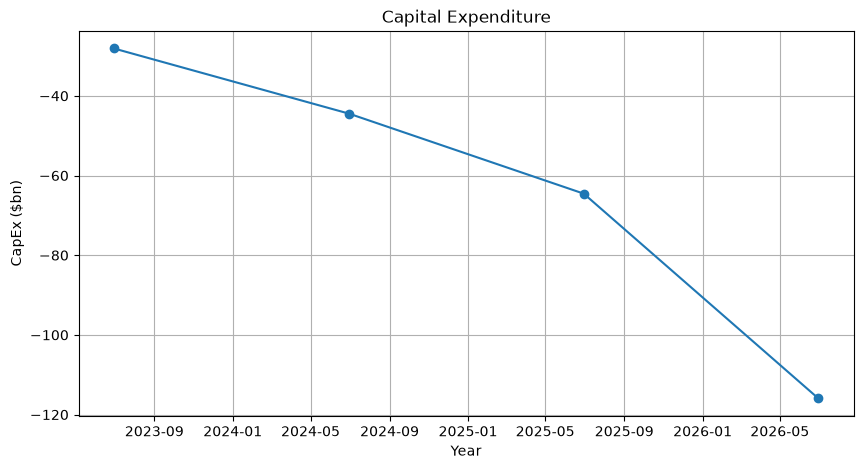

In [31]:
capital_expenditure = cash_flow["Capital Expenditure"]

capital_expenditure
plt.figure(figsize=(10,5))

plt.plot(
    capital_expenditure.index,
    capital_expenditure / 1e9,
    marker="o"
)

plt.title("Capital Expenditure")

plt.xlabel("Year")

plt.ylabel("CapEx ($bn)")

plt.grid(True)

plt.show()

### Free Cash Flow

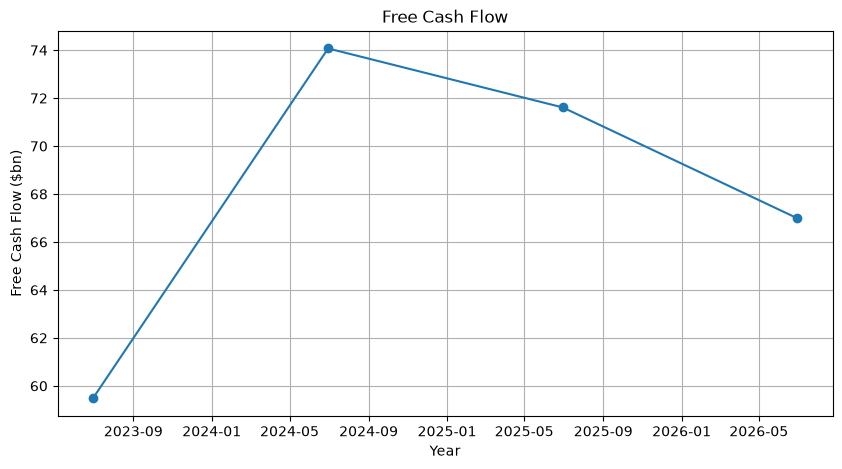

In [32]:
free_cash_flow = (
    operating_cash_flow + capital_expenditure
)

free_cash_flow

plt.figure(figsize=(10,5))

plt.plot(
    free_cash_flow.index,
    free_cash_flow / 1e9,
    marker="o"
)

plt.title("Free Cash Flow")

plt.xlabel("Year")

plt.ylabel("Free Cash Flow ($bn)")

plt.grid(True)

plt.show()

### Free Cash Flow Margin

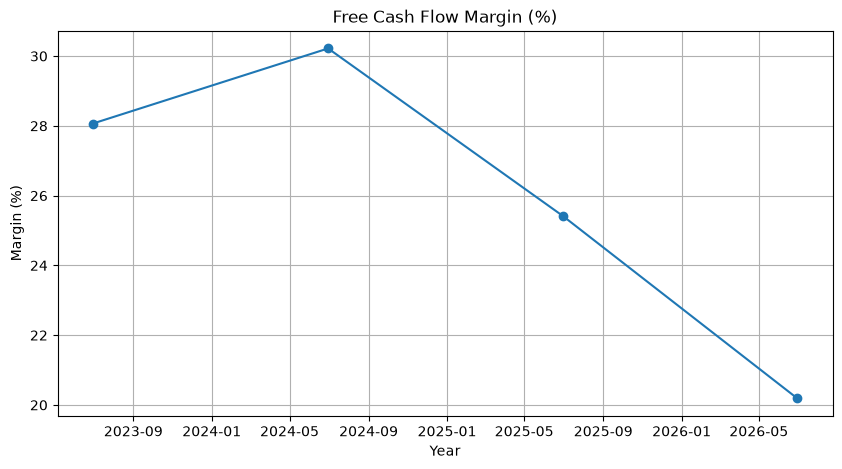

In [33]:
fcf_margin = (
    free_cash_flow /
    revenue
) * 100

fcf_margin

plt.figure(figsize=(10,5))

plt.plot(
    fcf_margin.index,
    fcf_margin,
    marker="o"
)

plt.title("Free Cash Flow Margin (%)")

plt.xlabel("Year")

plt.ylabel("Margin (%)")

plt.grid(True)

plt.show()

### Free Cash Flow Growth

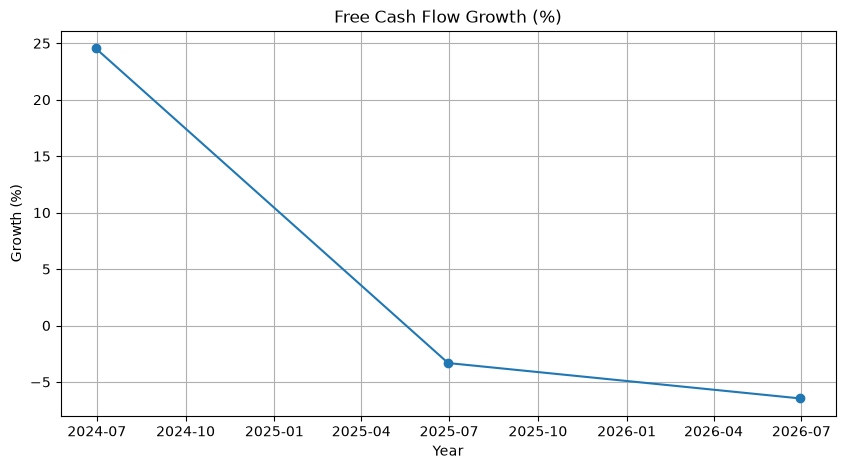

In [34]:
fcf_growth = (
    free_cash_flow
    .pct_change(-1, fill_method=None)
    * 100
)

fcf_growth

plt.figure(figsize=(10,5))

plt.plot(
    fcf_growth.index,
    fcf_growth,
    marker="o"
)

plt.title("Free Cash Flow Growth (%)")

plt.xlabel("Year")

plt.ylabel("Growth (%)")

plt.grid(True)

plt.show()

### Cash Flow Summary

In [35]:
cash_flow_summary = pd.DataFrame({

    "Operating Cash Flow": operating_cash_flow,
    "Capital Expenditure": capital_expenditure,
    "Free Cash Flow": free_cash_flow,
    "FCF Margin (%)": fcf_margin,
    "FCF Growth (%)": fcf_growth

})

cash_flow_summary

,Operating Cash Flow,Capital Expenditure,Free Cash Flow,FCF Margin (%),FCF Growth (%)
2022-06-30,NaN,NaN,NaN,NaN,NaN
2023-06-30,8.758200e+10,-2.810700e+10,5.947500e+10,28.065498,NaN
2024-06-30,1.185480e+11,-4.447700e+10,7.407100e+10,30.218014,24.541404
2025-06-30,1.361620e+11,-6.455100e+10,7.161100e+10,25.418850,-3.321138
2026-06-30,1.829350e+11,-1.159480e+11,6.698700e+10,20.186597,-6.457109


### Cash Flow Interpretation

In [47]:
import pandas as pd

latest_ocf = operating_cash_flow.dropna().iloc[0]
latest_fcf = free_cash_flow.dropna().iloc[0]
latest_fcf_margin = fcf_margin.dropna().iloc[-1]
latest_fcf_growth = fcf_growth.dropna().iloc[0]

ocf_values = operating_cash_flow.dropna()
fcf_values = free_cash_flow.dropna()
fcf_growth_values = fcf_growth.dropna()

print("CASH FLOW INTERPRETATION")
print("-" * 50)

if latest_ocf > 0:
    print(
        f"Operating cash flow is positive at ${latest_ocf:,.0f}, "
        "indicating that the company generated cash from its core operations."
    )
else:
    print(
        f"Operating cash flow is negative at ${latest_ocf:,.0f}, "
        "indicating that the company did not generate positive cash from its core operations."
    )

if latest_fcf > 0:
    print(
        f"Free cash flow is positive at ${latest_fcf:,.0f}, "
        "indicating that the company generated cash after capital expenditure."
    )
else:
    print(
        f"Free cash flow is negative at ${latest_fcf:,.0f}, "
        "indicating that capital expenditure exceeded operating cash generation."
    )

print(
    f"Free cash flow margin is {latest_fcf_margin:.2f}%, "
    "representing the proportion of revenue converted into free cash flow."
)

if latest_fcf_growth > 0:
    print(
        f"Free cash flow increased by {latest_fcf_growth:.2f}% "
        "compared with the previous period."
    )
elif latest_fcf_growth < 0:
    print(
        f"Free cash flow decreased by {abs(latest_fcf_growth):.2f}% "
        "compared with the previous period."
    )
else:
    print("Free cash flow was unchanged compared with the previous period.")

if len(fcf_values) >= 2:

    oldest_fcf = fcf_values.iloc[-1]
    latest_fcf = fcf_values.iloc[0]

    if latest_fcf > oldest_fcf:
        overall_change = ((latest_fcf - oldest_fcf) / abs(oldest_fcf)) * 100
        print(
            f"Overall, free cash flow has increased by {overall_change:.2f}% "
            "over the available historical period."
        )

    elif latest_fcf < oldest_fcf:
        overall_change = ((latest_fcf - oldest_fcf) / abs(oldest_fcf)) * 100
        print(
            f"Overall, free cash flow has decreased by {abs(overall_change):.2f}% "
            "over the available historical period."
        )

    else:
        print(
            "Overall, free cash flow has remained unchanged "
            "over the available historical period."
        )

CASH FLOW INTERPRETATION
--------------------------------------------------
Operating cash flow is positive at $182,935,000,000, indicating that the company generated cash from its core operations.
Free cash flow is positive at $66,987,000,000, indicating that the company generated cash after capital expenditure.
Free cash flow margin is 20.19%, representing the proportion of revenue converted into free cash flow.
Free cash flow decreased by 6.46% compared with the previous period.
Overall, free cash flow has increased by 12.63% over the available historical period.
